In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer

pd.set_option('display.max_columns', 50)
warnings.filterwarnings('ignore')

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


import datetime as dt
from category_encoders import CatBoostEncoder




### Базовое знакомство с данными

In [ ]:
df = pd.read_csv(
    'train.csv',
    parse_dates=['Deal_date', 'First_deal_date', 'First_default_date']
)
df[['Default', 'First_default_date']].head(50)

,Default,First_default_date
0,0,NaT
1,1,2016-07-30
2,0,NaT
3,0,NaT
4,0,NaT
5,1,NaT
6,0,NaT
7,0,NaT
8,0,NaT
9,0,NaT


In [ ]:
# что можно узнать о статистиках данных?
df.describe()

,Deal_id,Deal_date,First_deal_date,Secret_dwarf_info_1,Secret_dwarf_info_2,Secret_dwarf_info_3,First_default_date,Successful_deals_count,Tavern,Hashed_deal_detail_1,Hashed_deal_detail_2,Hashed_deal_detail_3,Hashed_deal_detail_4,Hashed_deal_detail_5,Hashed_deal_detail_6,Age,Default
count,3.168000e+03,3168,3168,535.000000,535.000000,535.000000,535,3154.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.0,3168.000000,3168.000000
mean,4.605727e+07,2016-04-11 12:55:54.545454,2015-10-24 04:21:49.090909,3.935514,-2.299065,5.267290,2016-01-10 23:16:56.074766,1.043754,13.350694,2.518939,-2.404356,8.462437,3.193813,-2.981692,5.0,36.411616,0.110795
min,5.856790e+05,2015-02-24 00:00:00,2015-02-10 00:00:00,2.500000,-3.000000,5.000000,2015-05-01 00:00:00,0.000000,2.000000,2.500000,-3.000000,5.000000,2.500000,-3.000000,5.0,20.000000,0.000000
25%,2.761608e+07,2016-01-21 00:00:00,2015-07-18 00:00:00,3.500000,-3.000000,5.000000,2015-10-30 00:00:00,0.000000,7.000000,2.500000,-3.000000,6.000000,2.500000,-3.000000,5.0,28.000000,0.000000
50%,4.349426e+07,2016-04-26 00:00:00,2015-10-27 00:00:00,3.500000,-2.000000,5.000000,2016-01-15 00:00:00,0.000000,8.000000,2.500000,-3.000000,8.000000,2.500000,-3.000000,5.0,34.000000,0.000000
75%,5.778544e+07,2016-07-28 00:00:00,2016-02-07 00:00:00,4.500000,-2.000000,5.000000,2016-04-15 00:00:00,2.000000,15.000000,2.500000,-3.000000,10.000000,2.500000,-3.000000,5.0,43.000000,0.000000
max,6.927701e+08,2016-09-30 00:00:00,2016-09-14 00:00:00,9.500000,2.000000,8.000000,2016-09-13 00:00:00,17.000000,58.000000,17.500000,78.000000,29.000000,37.500000,4.000000,5.0,72.000000,1.000000
std,5.370953e+07,NaN,NaN,0.888467,0.734579,0.498645,NaN,1.649416,8.851891,0.351308,2.474564,3.521127,2.048743,0.245540,0.0,10.821444,0.313928


Первое, что бросается в глаза - дефицит записей (пропуски) в некоторых колонках, а также константный признак - Hashed_deal_detail_6. Вернемся к ним чуть позже.

### EDA

Посмотрим на баланс классов в датасете

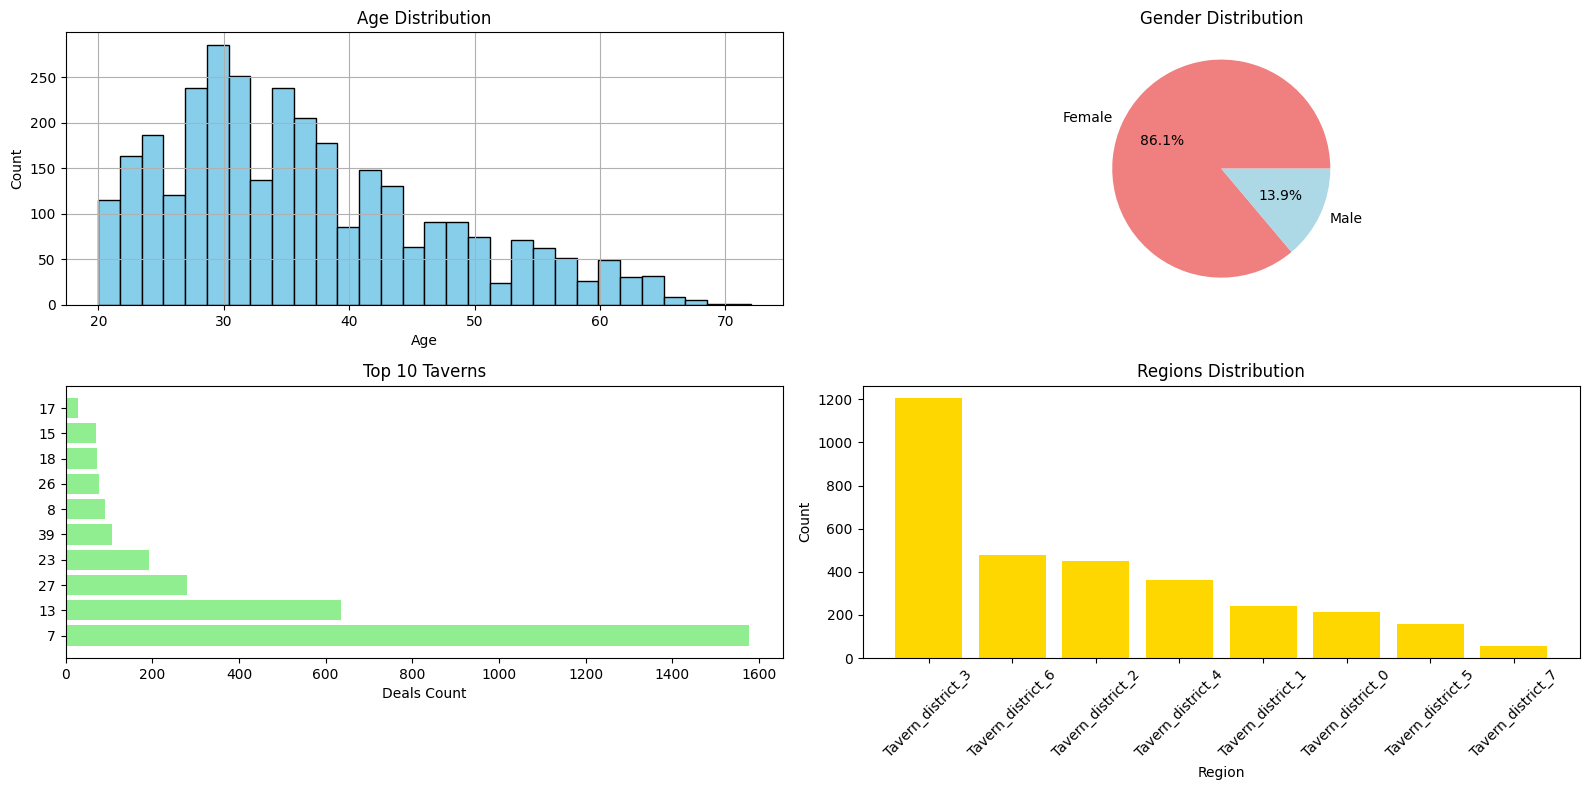

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16,8))                 # как распределен возраст клиентов?
df['Age'].hist(bins=30, ax=axes[0,0], color='skyblue', edgecolor='black')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')

gender_counts = df['Gender'].value_counts()                                 # есть ли перевес определенного пола?
axes[0,1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightblue'])
axes[0,1].set_title('Gender Distribution')

tavern_top10 = df['Tavern'].value_counts().head(10)                         # популярность каждого заведения
axes[1,0].barh(range(len(tavern_top10)), tavern_top10.values, color='lightgreen')
axes[1,0].set_yticks(range(len(tavern_top10)))
axes[1,0].set_yticklabels(tavern_top10.index)
axes[1,0].set_title('Top 10 Taverns')
axes[1,0].set_xlabel('Deals Count')

reg_counts = df['Region'].value_counts()                                    # частота встречаемости каждого региона
axes[1,1].bar(reg_counts.index, reg_counts.values, color='gold')
axes[1,1].set_title('Regions Distribution')
axes[1,1].set_xlabel('Region')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

#### Временная структура

Так как у нас есть временные колонки, важно проверить: есть ли drift по времени?

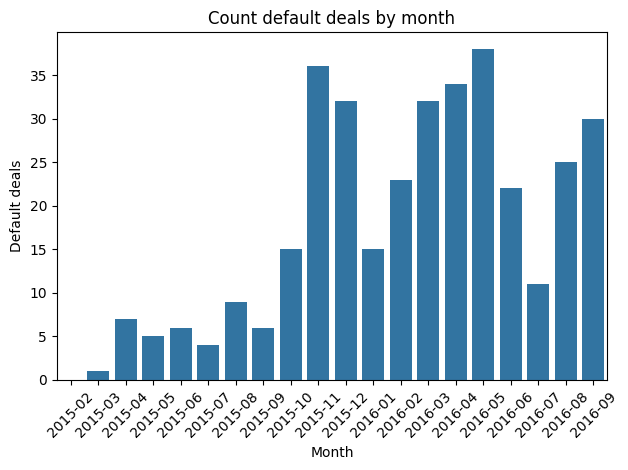

In [ ]:
monthly_stats = (
    df.assign(Deal_month=df['Deal_date'].dt.to_period('M').astype(str))
      .groupby('Deal_month')
      .agg(
          default_rate=('Default', 'mean'),
          defaults=('Default', 'sum')
      )
      .reset_index()
      .sort_values('Deal_month')
)
ax = sns.barplot(
    data=monthly_stats,
    x='Deal_month',
    y='defaults'
)
ax.set_title('Count default deals by month')
ax.set_xlabel('Month')
ax.set_ylabel('Default deals')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
df.assign(Deal_month=df['Deal_date'].dt.to_period('M').astype(str)).groupby('Deal_month').agg(default_rate=('Default', 'mean'),
deals=('Default', 'count')
).reset_index().sort_values('default_rate')

,Deal_month,default_rate,deals
0,2015-02,0.000000,2
17,2016-07,0.046809,235
18,2016-08,0.069638,359
19,2016-09,0.075188,399
16,2016-06,0.085603,257
13,2016-03,0.104575,306
11,2016-01,0.110294,136
7,2015-09,0.122449,49
14,2016-04,0.123188,276
12,2016-02,0.127778,180


Доля дефолтов заметно меняется по времени, а значит случайное разбиение исказит оценку качества. Следовательно, позже я буду использовать **временной holdout**: последние 20% наблюдений оставлю как псевдо-будущее

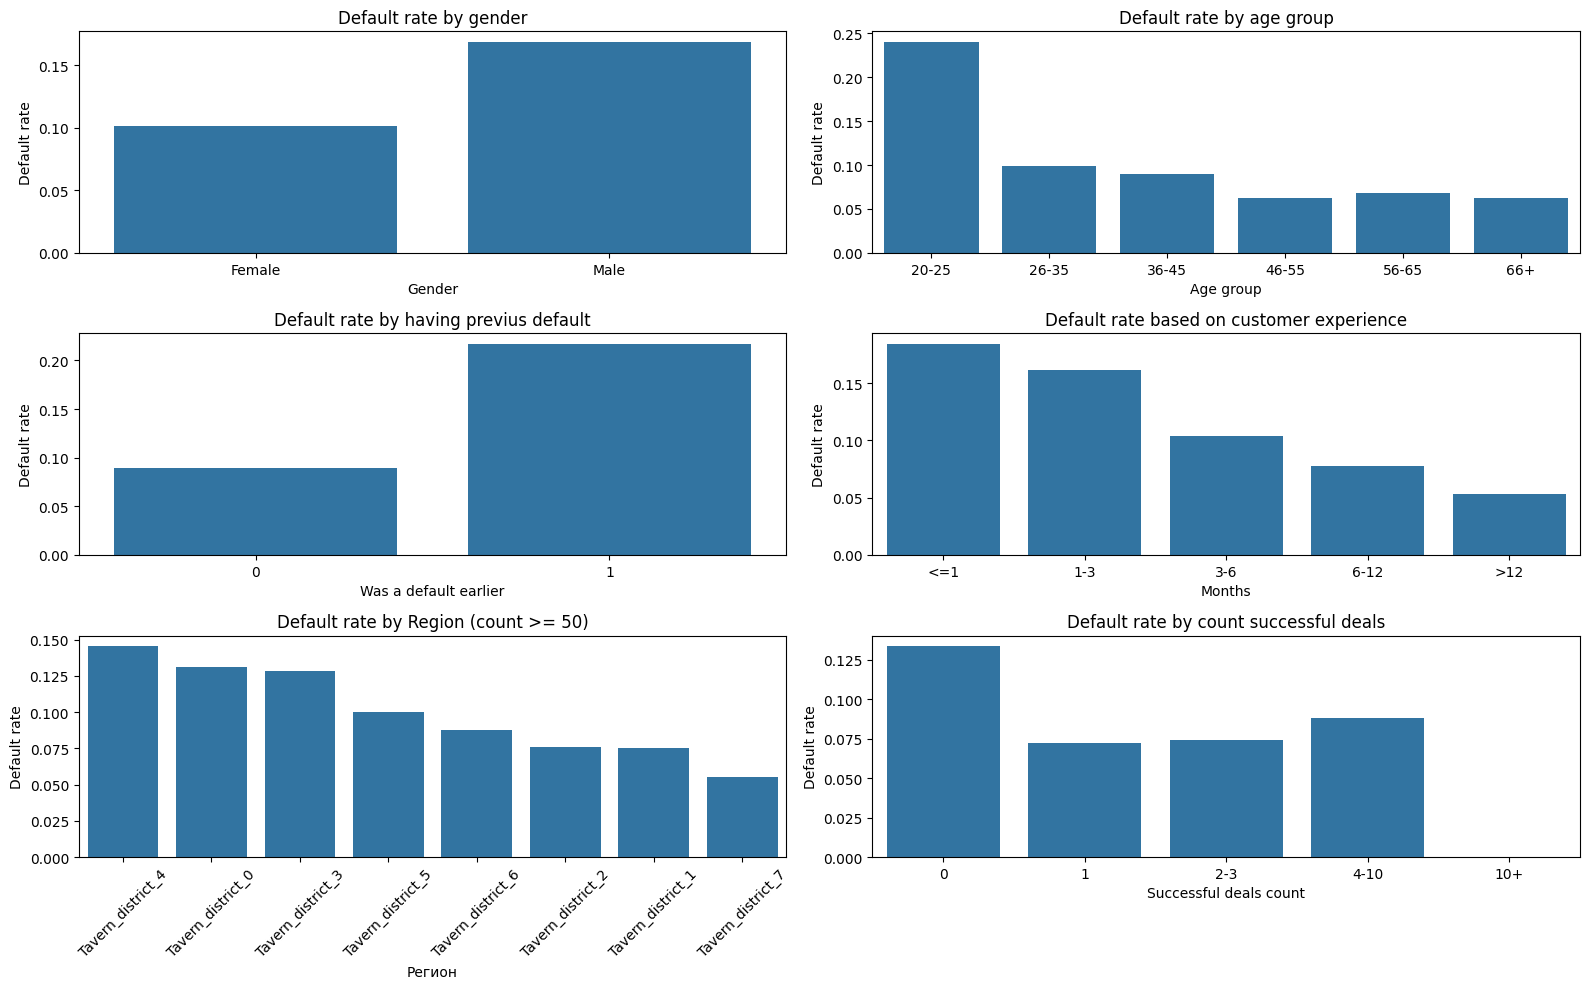

,Region,Default_rate,Deals
0,Tavern_district_4,0.145604,364
1,Tavern_district_0,0.131455,213
2,Tavern_district_3,0.128738,1204
3,Tavern_district_5,0.100000,160
4,Tavern_district_6,0.087866,478
5,Tavern_district_2,0.075893,448
6,Tavern_district_1,0.075000,240
7,Tavern_district_7,0.055556,54


,Deals_bucket,Default_rate,Deals
0,0,0.133542,1917
1,1,0.072165,194
2,2-3,0.074163,836
3,4-10,0.087963,216
4,10+,0.000000,5


In [ ]:
eda_df = df.copy()
eda_df['Has_previous_default'] = eda_df['First_default_date'].notna().astype(int)
eda_df['Days_since_first_deal'] = (eda_df['Deal_date'] - eda_df['First_deal_date']).dt.days
eda_df['Age_bucket'] = pd.cut(
    eda_df['Age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['20-25', '26-35', '36-45', '46-55', '56-65', '66+'],
)
eda_df['Tenure_bucket'] = pd.cut(
    eda_df['Days_since_first_deal'],
    bins=[-1, 30, 90, 180, 365, 10_000],
    labels=['<=1', '1-3', '3-6', '6-12', '>12']
)
eda_df['Deals_bucket'] = pd.cut(
    eda_df['Successful_deals_count'].fillna(0),
    bins=[-1, 0, 1, 3, 10, 1_000],
    labels=['0', '1', '2-3', '4-10', '10+']
)

region_stats = (
    eda_df.groupby('Region', dropna=False)['Default']
    .agg(Default_rate='mean', Deals='size')
    .query('Deals >= 50')
    .sort_values('Default_rate', ascending=False)
    .reset_index()
)

deals_stats = (
    eda_df.groupby('Deals_bucket', observed=False)['Default']
    .agg(Default_rate='mean', Deals='size')
    .reset_index()
)
gender_stats = eda_df.groupby('Gender', dropna=False)['Default'].agg(['mean', 'count']).reset_index()
age_stats = eda_df.groupby('Age_bucket', observed=False)['Default'].agg(['mean', 'count']).reset_index()
history_stats = eda_df.groupby('Has_previous_default')['Default'].agg(['mean', 'count']).reset_index()
tenure_stats = eda_df.groupby('Tenure_bucket', observed=False)['Default'].agg(['mean', 'count']).reset_index()

fig, axes = plt.subplots(3, 2, figsize=(16, 10))

sns.barplot(data=gender_stats, x='Gender', y='mean', ax=axes[0, 0])
axes[0, 0].set_title('Default rate by gender')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].set_ylabel('Default rate')

sns.barplot(data=age_stats, x='Age_bucket', y='mean', ax=axes[0, 1])
axes[0, 1].set_title('Default rate by age group')
axes[0, 1].set_xlabel('Age group')
axes[0, 1].set_ylabel('Default rate')

sns.barplot(data=history_stats, x='Has_previous_default', y='mean', ax=axes[1, 0])
axes[1, 0].set_title('Default rate by having previus default')
axes[1, 0].set_xlabel('Was a default earlier')
axes[1, 0].set_ylabel('Default rate')

sns.barplot(data=tenure_stats, x='Tenure_bucket', y='mean', ax=axes[1, 1])
axes[1, 1].set_title('Default rate based on customer experience')
axes[1, 1].set_xlabel('Months')
axes[1, 1].set_ylabel('Default rate')

sns.barplot(data=region_stats, x='Region', y='Default_rate', ax=axes[2, 0])
axes[2, 0].set_title('Default rate by Region (count >= 50)')
axes[2, 0].set_xlabel('Регион')
axes[2, 0].set_ylabel('Default rate')
axes[2, 0].tick_params(axis='x', rotation=45)

sns.barplot(data=deals_stats, x='Deals_bucket', y='Default_rate', ax=axes[2, 1])
axes[2, 1].set_title('Default rate by count successful deals')
axes[2, 1].set_xlabel('Successful deals count')
axes[2, 1].set_ylabel('Default rate')

plt.tight_layout()
plt.show()

display(region_stats)
display(deals_stats)

На уровне EDA уже просматриваются содержательные закономерности:

- у клиентов с дефолтом в истории риск выше;
- молодые клиенты более склонны к дефолту, чем старшие возрастные группы;
- чем меньше стаж клиента, тем выше вероятность дефолта;
- пол тоже влияет на вероятность дефолта

На основе данных выводов далее сгенерируем фичи

Посмотрим на попарную корреляцию

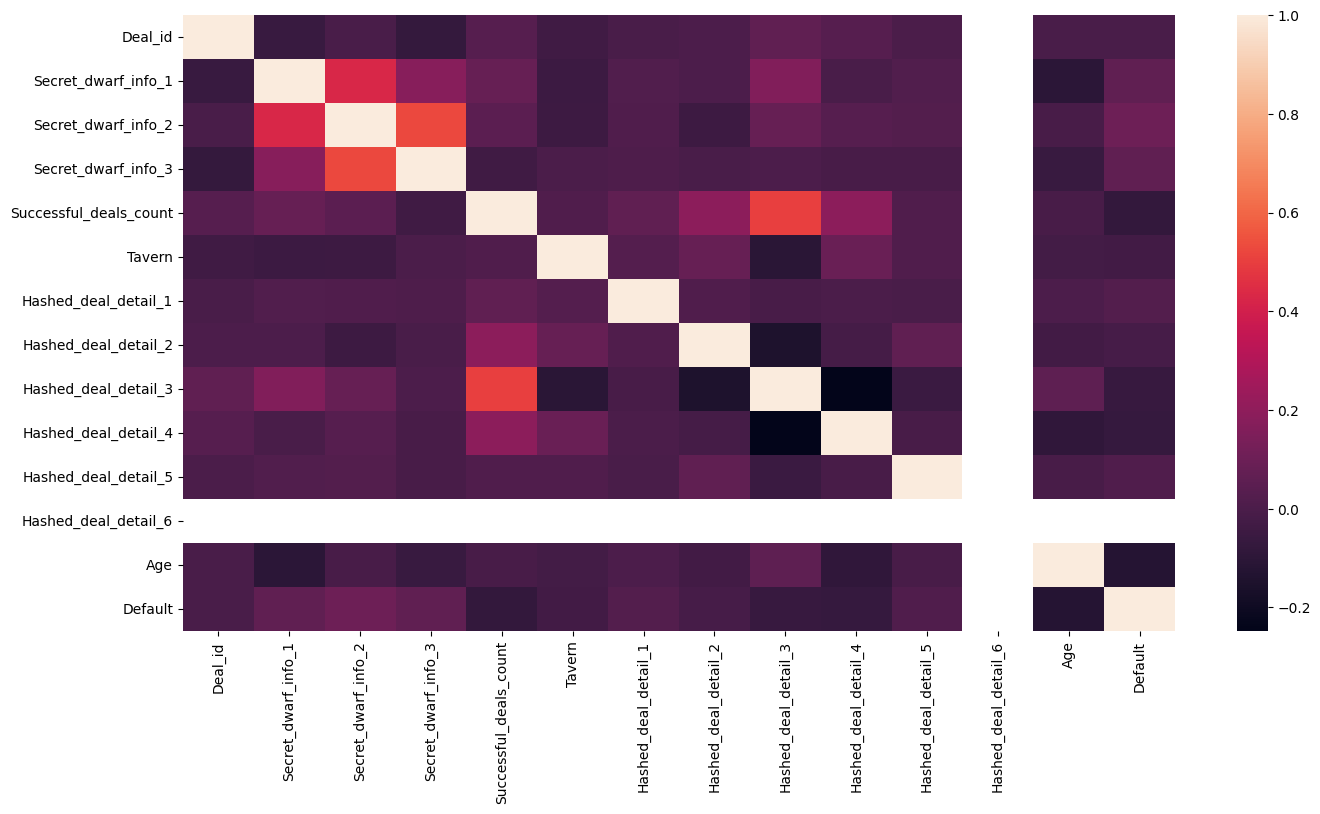

In [ ]:
plt.figure(figsize=(16,8))
sns.heatmap(df.corr(numeric_only=True), xticklabels=True, yticklabels=True)
plt.show()

Выводы: Признаки между собой не скоррелированы. Есть значительный дисбаланс в классах (см. графики выше). Повторим также, что Hashed_deal_detail_6 является константой, удалим его во избежание мультиколлинеарности и лишних вычислений

In [ ]:
df = df.drop('Hashed_deal_detail_6', axis=1)

In [ ]:
df.info() # посмотрим на типы данных

<class 'pandas.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Deal_id                 3168 non-null   int64         
 1   Deal_date               3168 non-null   datetime64[us]
 2   First_deal_date         3168 non-null   datetime64[us]
 3   Secret_dwarf_info_1     535 non-null    float64       
 4   Secret_dwarf_info_2     535 non-null    float64       
 5   Secret_dwarf_info_3     535 non-null    float64       
 6   First_default_date      535 non-null    datetime64[us]
 7   Successful_deals_count  3154 non-null   float64       
 8   Region                  3161 non-null   str           
 9   Tavern                  3168 non-null   int64         
 10  Hashed_deal_detail_1    3168 non-null   float64       
 11  Hashed_deal_detail_2    3168 non-null   int64         
 12  Hashed_deal_detail_3    3168 non-null   int64         
 13 

### Заполнение пропусков

Поработаем с пропусками в данных

In [ ]:
print(f'Пропуски в данных:\n{df.isna().sum()}')

Пропуски в данных:
Deal_id                      0
Deal_date                    0
First_deal_date              0
Secret_dwarf_info_1       2633
Secret_dwarf_info_2       2633
Secret_dwarf_info_3       2633
First_default_date        2633
Successful_deals_count      14
Region                       7
Tavern                       0
Hashed_deal_detail_1         0
Hashed_deal_detail_2         0
Hashed_deal_detail_3         0
Hashed_deal_detail_4         0
Hashed_deal_detail_5         0
Age                          0
Gender                       0
Default                      0
dtype: int64


Идея: на засекреченных признаках (Secrets_dwarf_info) заполним пропуски средним, в регионе - новой категорией 'Unknown', записи в колонке с успешными сделками - нулем. В First_default_date заполним NaN константой '2000-01-01' - "выбросом", чтобы в признаковом пространстве подальше отделить объекты с пропуском в этой колонке

Пропишем функцию для применимости и к train, и к test

In [ ]:
def fill_values(train, eval):
    for i in range(1,4):
        cols = f'Secret_dwarf_info_{i}'
        train[cols] = train[cols].fillna(train[cols].mean())
        eval[cols] = eval[cols].fillna(train[cols].mean())

    values = {
        'Region': 'Unknown',
        'Successful_deals_count': 0
    }

    train.update(train[['Region', 'Successful_deals_count']].fillna(values))
    eval.update(eval[['Region', 'Successful_deals_count']].fillna(values))

    train.update(train['First_default_date'].fillna('2010-01-01'))
    eval.update(eval['First_default_date'].fillna('2010-01-01'))

    return train, eval

### Создание новых признаков и обработка Encoding-ом

На этом этапе раскодируем колонку 'Region' и 'Gender': использование encoder-a от CatBoost подойдет по причине временной структуры данных. После сортировки записей по времени значение колонки будет считаться только по актуальным данным на текущий момент, без утечки (data leakage). На тесте же применятся последние значения из теста для каждого региона. 

Мотивация раскодирования пола: выше (в блоке EDA) мы увидели, что Default Rate у полов разный, поэтому имеет смысл заполнить значения средними вероятностями дефолта, специфичными для каждой группы

In [ ]:
def encode(train, eval):
    train.sort_values('Deal_date', inplace=True)

    encoder = CatBoostEncoder(cols=['Region', 'Gender'])
    train[['Region', 'Gender']] = encoder.fit_transform(train[['Region', 'Gender']], train['Default'])
    eval[['Region', 'Gender']] = encoder.transform(eval[['Region', 'Gender']])

    return train, eval

# def encode(train, eval):
#     train.sort_values('Deal_date', inplace=True)

#     encoder = CatBoostEncoder(cols='Region')
#     train['Region'] = encoder.fit_transform(train['Region'], train['Default'])
#     eval['Region'] = encoder.transform(eval['Region'])

#     return train, eval

Колонку с датами распарсим на дополнительные признаки и создадим 4 фичи поверх имеющихся

In [ ]:
def date_features(df):
    # первая фича - "покупной возраст клиента" - разница между текущей и первой покупками
    df['Days_since_first_deal'] = (df['Deal_date'] - df['First_deal_date']).dt.days

    # агрегированные фичи по клиентской истории

    # третья - стаж клиента в месяцах, по идее, более стабильная (не слишком шумная) статистика, чем дни
    df['Client_tenure_months'] = np.floor(df['Days_since_first_deal'] / 30).astype(int)

    # четвертый признак - показатель активности клиента (LTV-подобная метрика)
    df['Deals_per_tenure_month'] = (
    df['Successful_deals_count'] / np.maximum(df['Client_tenure_months'], 1)
    )

    # пятый - возрастная группа, как дополнительная нелинейная проекция
    df['Age_bucket'] = pd.cut(df['Age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+']).astype(str)

    # df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

    return df

Колонку с датой сделки теперь можно распарсить на год-месяц-дата-день недели

In [ ]:
def date_parse(df):
    df['Year_deal'] = df.Deal_date.dt.year
    df['Month_deal'] = df.Deal_date.dt.month               
    df['Day_deal'] = df.Deal_date.dt.day
    df['Day_of_week_deal'] = df.Deal_date.dt.dayofweek
    
    df['Year_first_deal'] = df.First_deal_date.dt.year
    df['Month_first_deal'] = df.First_deal_date.dt.month
    df['Day_first_deal'] = df.First_deal_date.dt.day      # не создаем здесь признак по дню недели, так как впоследствии он будет сильно
                                                          # коррелировать с другими колонками (выявлено эмпирически)

    df['Year_first_default'] = df.First_default_date.dt.year
    df['Month_first_default'] = df.First_default_date.dt.month
    df['Day_first_default'] = df.First_default_date.dt.day
    df['Day_of_week_first_default'] = df.First_deal_date.dt.dayofweek

    df.drop(['Deal_date', 'First_deal_date', 'First_default_date'], axis=1, inplace=True)

    return df

Для применения написанных выше функций, чтобы все корректно отработало, разобьем датасет на тренировочные данные и тестовые

### Подготовка данных к обучению

Разделим датасет на трейн и тест. Проверим долю таргета после сплитования

In [ ]:
df.sort_values('Deal_date', inplace=True) # для корректного разбиения временных данных будем использовать срезы,
                                            # но перед этим обязательно отсортируем по дате сделки
split_idx = int(len(df) * 0.8)
df_train = df.loc[df.index[:split_idx]]
df_test = df.loc[df.index[split_idx:]]

train_shares = df_train["Default"].value_counts() / df_train.shape[0]
test_shares = df_test["Default"].value_counts() / df_test.shape[0]

to_compare = pd.concat((train_shares, test_shares), axis=1)
to_compare.columns = ['Доля в трейне', 'Доля в тесте']
to_compare['Абсолютная разница'] = (to_compare["Доля в трейне"] -
                                    to_compare["Доля в тесте"]).abs()

to_compare

,Доля в трейне,Доля в тесте,Абсолютная разница
Default,,,
0,0.879637,0.927445,0.047808
1,0.120363,0.072555,0.047808


In [ ]:
# применим все написанные функции
fill_values(train=df_train, eval=df_test)
date_features(df_train)
date_features(df_test)
encode(df_train, df_test)
date_parse(df_train)
date_parse(df_test)

,Deal_id,Secret_dwarf_info_1,Secret_dwarf_info_2,Secret_dwarf_info_3,Successful_deals_count,Region,Tavern,Hashed_deal_detail_1,Hashed_deal_detail_2,Hashed_deal_detail_3,Hashed_deal_detail_4,Hashed_deal_detail_5,Age,Gender,Default,Days_since_first_deal,Client_tenure_months,Deals_per_tenure_month,Age_bucket,Year_deal,Month_deal,Day_deal,Day_of_week_deal,Year_first_deal,Month_first_deal,Day_first_deal,Year_first_default,Month_first_default,Day_first_default,Day_of_week_first_default
1531,6068711,3.92619,-2.311905,5.266667,0.0,0.086411,7,2.5,-2,7,2.5,-3,50.0,0.11066,0,123,4,0.000,46-55,2016,8,14,6,2016,4,13,2010,1,1,2
372,60640066,3.92619,-2.311905,5.266667,1.0,0.134059,7,2.5,-3,14,2.5,-3,36.0,0.11066,0,263,8,0.125,36-45,2016,8,14,6,2015,11,25,2010,1,1,2
2938,60681517,3.92619,-2.311905,5.266667,4.0,0.086411,13,2.5,-3,13,3.5,-3,34.0,0.11066,0,254,8,0.500,26-35,2016,8,14,6,2015,12,4,2010,1,1,4
2137,60605410,3.92619,-2.311905,5.266667,2.0,0.106670,13,2.5,-3,5,8.5,-3,35.0,0.11066,0,307,10,0.200,26-35,2016,8,14,6,2015,10,12,2010,1,1,0
466,60607717,3.92619,-2.311905,5.266667,1.0,0.099562,8,2.5,-3,17,2.5,-3,38.0,0.11066,0,264,8,0.125,36-45,2016,8,14,6,2015,11,24,2010,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762,69498350,3.92619,-2.311905,5.266667,0.0,0.101611,8,2.5,-3,5,5.5,-3,26.0,0.11066,0,132,4,0.000,26-35,2016,9,30,4,2016,5,21,2010,1,1,5
1980,69320781,3.92619,-2.311905,5.266667,0.0,0.143494,7,2.5,-3,5,5.5,-3,33.0,0.11066,0,72,2,0.000,26-35,2016,9,30,4,2016,7,20,2010,1,1,2
2149,69474914,3.92619,-2.311905,5.266667,4.0,0.101611,27,2.5,-3,5,13.5,-3,30.0,0.11066,0,317,10,0.400,26-35,2016,9,30,4,2015,11,18,2010,1,1,2
97,69525076,3.92619,-2.311905,5.266667,0.0,0.049311,13,2.5,-3,7,2.5,-3,20.0,0.11066,1,78,2,0.000,18-25,2016,9,30,4,2016,7,14,2010,1,1,3


In [ ]:
print(f'Количество пропусков в тренировочных данных: {df_train.isna().sum().sum()}')
print('-' * 45)
print(f'Количество пропусков в тестовых данных: {df_test.isna().sum().sum()}')

Количество пропусков в тренировочных данных: 0
---------------------------------------------
Количество пропусков в тестовых данных: 0


Далее делим на признаки и таргет, также убираем колонку с id сделки, так как эта информация избыточна для обучения

In [ ]:
X_train = df_train.drop(['Default', 'Deal_id'], axis=1)
y_train = df_train['Default']
X_test = df_test.drop(['Default', 'Deal_id'], axis=1)
y_test = df_test['Default']

Сформируем списки колонок для последующего использования в ColumnTransformer

In [ ]:
numeric_cols = ['Secret_dwarf_info_1', 'Secret_dwarf_info_2', 'Secret_dwarf_info_3', 'Successful_deals_count',
                'Hashed_deal_detail_1', 'Hashed_deal_detail_2', 'Hashed_deal_detail_3', 'Hashed_deal_detail_4', 'Hashed_deal_detail_5',
                'Days_since_first_deal', 'Client_tenure_months', 'Deals_per_tenure_month']
categorical_cols = ['Region', 'Tavern', 'Gender', 'Age_bucket', 'Age', 'Year_deal', 'Month_deal', 'Day_deal', 
                    'Day_of_week_deal', 'Year_first_deal', 'Month_first_deal', 'Day_first_deal', 
                    'Year_first_default', 'Month_first_default', 'Day_first_default', 'Day_of_week_first_default']
print(f'Числовые признаки: {numeric_cols}')
print(f'Категориальные признаки: {categorical_cols}')

Числовые признаки: ['Secret_dwarf_info_1', 'Secret_dwarf_info_2', 'Secret_dwarf_info_3', 'Successful_deals_count', 'Hashed_deal_detail_1', 'Hashed_deal_detail_2', 'Hashed_deal_detail_3', 'Hashed_deal_detail_4', 'Hashed_deal_detail_5', 'Days_since_first_deal', 'Client_tenure_months', 'Deals_per_tenure_month']
Категориальные признаки: ['Region', 'Tavern', 'Gender', 'Age_bucket', 'Age', 'Year_deal', 'Month_deal', 'Day_deal', 'Day_of_week_deal', 'Year_first_deal', 'Month_first_deal', 'Day_first_deal', 'Year_first_default', 'Month_first_default', 'Day_first_default', 'Day_of_week_first_default']


### Почему здесь важнее PR-AUC, чем accuracy

При доле дефолтов около 11% модель, которая всегда предсказывает ноль, уже покажет высокую accuracy. Для такого датасета это плохой ориентир.

### Инициализация моделей

Сравним 3 модели:

1. `LogisticRegression` как интерпретируемый baseline.
2. `kNN` как метрический алгоритм.
3. `RandomForest` как bagging + случайный выбор подпространства признаков.

От бустинга здесь сознательно отходим: он почти наверняка еще добавит качества, но в этом проекте важнее проверить качество классических ансамблей


In [ ]:
def build_linear_preprocessor():
    return ColumnTransformer(
        [
            ('num', StandardScaler(), numeric_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_cols)
        ]
    )

def build_trees_preprocessor():
    return ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)])
    

In [ ]:
def build_models():
    linear_preprocessor = build_linear_preprocessor()
    tree_preprocessor = build_trees_preprocessor()

    models = {
            'LogisticRegression': Pipeline(
                [
                    ('preprocessor', linear_preprocessor),
                    ('model', LogisticRegression(class_weight='balanced', random_state=42)),
                ]
            ),

            'kNN': Pipeline(
                [('preprocessing', linear_preprocessor),
                 ('model', KNeighborsClassifier())]
            ),

            'RandomForest': Pipeline(
                [('preprocessor', tree_preprocessor),
                 ('model', RandomForestClassifier(n_estimators=150,
                                                  max_depth=8,
                                                  min_samples_leaf=5,
                                                  class_weight='balanced_subsample',
                                                  random_state=42,
                                                  n_jobs=-1))
                ]
            )
    }

    return models

#### Функция для оценки моделей
Так как у нас сильный дисбаланс классов, основной метрикой будет выступать **PR-AUC** (Area Under the Precision-Recall Curve). Напишем функцию, которая обучит модель, выведет метрики на Train и Test, а также отрисует кривую

In [ ]:
def evaluate_model(model_name, pipeline, X_train, y_train, X_test, y_test):
    print(f'Обучение модели: {model_name}')
    
    pipeline.fit(X_train, y_train)
    
    y_prob_train = pipeline.predict_proba(X_train)[:, 1]
    y_prob_test = pipeline.predict_proba(X_test)[:, 1]
    
    pr_auc_train = average_precision_score(y_train, y_prob_train)
    pr_auc_test = average_precision_score(y_test, y_prob_test)
    
    print(f'PR-AUC на трейне: {pr_auc_train:.3f}')
    print(f'PR-AUC на тесте: {pr_auc_test:.3f}')
    
    # Отрисовка PR-кривой
    fig, ax = plt.subplots(figsize=(6, 4))
    PrecisionRecallDisplay.from_estimator(pipeline, X_test, y_test, ax=ax, name=model_name)
    plt.title(f'PR Curve: {model_name}')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    
    return pipeline

Обучение модели: kNN


/Users/lefukuro/Documents/ml_env/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2, 4, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/lefukuro/Documents/ml_env/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2, 4, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


PR-AUC на трейне: 0.416
PR-AUC на тесте: 0.138


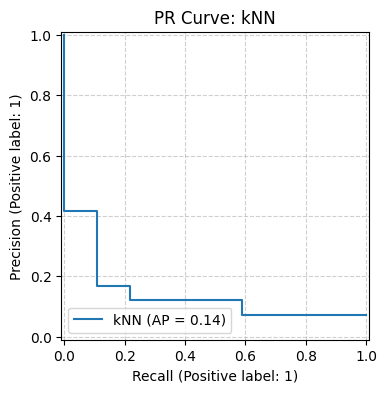

In [ ]:
knn_model = evaluate_model('kNN', build_models()['kNN'], X_train, y_train, X_test, y_test)

Обучение модели: Logistic Regression
PR-AUC на трейне: 0.955
PR-AUC на тесте: 0.190


/Users/lefukuro/Documents/ml_env/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2, 4, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/lefukuro/Documents/ml_env/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2, 4, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


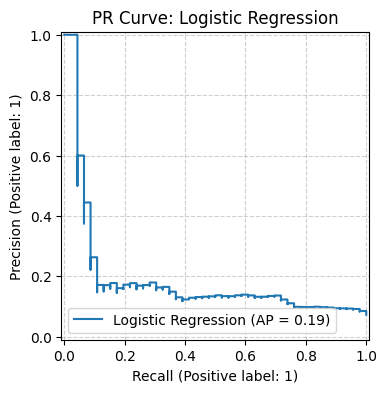

In [ ]:
lr_model = evaluate_model('Logistic Regression', build_models()['LogisticRegression'], X_train, y_train, X_test, y_test)

In [ ]:
y_pred = lr_model.predict(X_test)
print(classification_report(y_test, y_pred))

/Users/lefukuro/Documents/ml_env/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2, 4, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


              precision    recall  f1-score   support

           0       0.93      0.96      0.94       588
           1       0.16      0.11      0.13        46

    accuracy                           0.89       634
   macro avg       0.55      0.53      0.54       634
weighted avg       0.88      0.89      0.88       634



#### Вывод по логистической регрессии:
Без тюнинга гиперпараметров очевидно, что модель не пригодна для прогнозирования, предсказание класса 1 идет путем большого количества ложных "срабатываний" - почти каждый пятый ответ "1" верный. Можно посмотреть в сторону случайного и ансамблей

Построим модель RandomForestClassifier, переберем гиперпараметры и сравним результаты с логистической регрессией.

In [ ]:
feature_importance = pd.DataFrame({
    'Columns': X_test.columns,
    'Importance': per.importances_mean,
    'STD': per.importances_std
}).sort_values(by='Importance', ascending=True)
display(feature_importance)

,Columns,Importance,STD
20,Day_of_week_deal,-0.006309,0.003733
19,Day_deal,-0.005047,0.004506
1,Secret_dwarf_info_2,-0.004416,0.002318
26,Day_first_default,-0.003785,0.001893
25,Month_first_default,-0.003470,0.002093
9,Hashed_deal_detail_4,-0.003155,0.001728
21,Year_first_deal,-0.002208,0.003398
22,Month_first_deal,-0.001577,0.006149
16,Age_bucket,-0.001577,0.004348
8,Hashed_deal_detail_3,-0.001577,0.002639


In [ ]:
X_test.columns

Index(['Secret_dwarf_info_1', 'Secret_dwarf_info_2', 'Secret_dwarf_info_3',
       'Successful_deals_count', 'Region', 'Tavern', 'Hashed_deal_detail_1',
       'Hashed_deal_detail_2', 'Hashed_deal_detail_3', 'Hashed_deal_detail_4',
       'Hashed_deal_detail_5', 'Age', 'Gender', 'Days_since_first_deal',
       'Client_tenure_months', 'Deals_per_tenure_month', 'Age_bucket',
       'Year_deal', 'Month_deal', 'Day_deal', 'Day_of_week_deal',
       'Year_first_deal', 'Month_first_deal', 'Day_first_deal',
       'Year_first_default', 'Month_first_default', 'Day_first_default',
       'Day_of_week_first_default'],
      dtype='str')

In [ ]:
X_test.describe()

,Secret_dwarf_info_1,Secret_dwarf_info_2,Secret_dwarf_info_3,Successful_deals_count,Region,Tavern,Hashed_deal_detail_1,Hashed_deal_detail_2,Hashed_deal_detail_3,Hashed_deal_detail_4,Hashed_deal_detail_5,Age,Gender,Days_since_first_deal,Days_before_first_default,Client_tenure_months,Deals_per_tenure_month,Year_deal,Month_deal,Day_deal,Day_of_week_deal,Year_first_deal,Month_first_deal,Day_first_deal,Year_first_default,Month_first_default,Day_first_default,Day_of_week_first_default
count,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.0,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000
mean,3.934058,-2.301070,5.267192,1.605678,0.117171,13.227129,2.531546,-2.186120,9.462145,3.711356,-2.984227,36.981073,0.122224,229.279180,1795.381703,7.173502,0.190122,2016.0,8.629338,18.750789,3.209779,2015.575710,6.304416,15.949527,2011.066246,1.810726,3.624606,3.097792
std,0.422175,0.292137,0.233945,2.147565,0.027274,9.568188,0.384061,4.161062,4.286278,2.956151,0.286181,10.172584,0.026585,137.055354,918.327205,4.581182,0.260451,0.0,0.483364,8.089021,1.973401,0.494625,3.207970,8.577901,2.271194,2.105918,6.776115,1.961694
min,3.500000,-3.000000,5.000000,0.000000,0.049311,7.000000,2.500000,-3.000000,5.000000,2.500000,-3.000000,20.000000,0.110660,2.000000,-524.000000,0.000000,0.000000,2016.0,8.000000,1.000000,0.000000,2015.000000,1.000000,1.000000,2010.000000,1.000000,1.000000,0.000000
25%,3.926190,-2.311905,5.266667,0.000000,0.099562,7.000000,2.500000,-3.000000,6.000000,2.500000,-3.000000,29.000000,0.110660,120.250000,1979.000000,4.000000,0.000000,2016.0,8.000000,14.000000,2.000000,2015.000000,4.000000,9.000000,2010.000000,1.000000,1.000000,2.000000
50%,3.926190,-2.311905,5.266667,1.000000,0.134059,8.000000,2.500000,-3.000000,8.000000,2.500000,-3.000000,36.000000,0.110660,200.500000,2197.500000,6.000000,0.111111,2016.0,9.000000,20.000000,3.000000,2016.000000,6.000000,16.000000,2010.000000,1.000000,1.000000,3.000000
75%,3.926190,-2.311905,5.266667,2.000000,0.134059,13.000000,2.500000,-3.000000,12.000000,3.500000,-3.000000,43.000000,0.110660,315.750000,2313.750000,10.000000,0.333333,2016.0,9.000000,25.000000,5.000000,2016.000000,9.000000,23.000000,2010.000000,1.000000,1.000000,5.000000
max,9.500000,0.000000,8.000000,17.000000,0.353394,58.000000,10.500000,78.000000,29.000000,37.500000,4.000000,69.000000,0.183246,583.000000,2448.000000,19.000000,2.000000,2016.0,9.000000,31.000000,6.000000,2016.000000,12.000000,31.000000,2016.000000,12.000000,30.000000,6.000000
